In [1]:
using Pkg
Pkg.activate(".")
# Pkg.instantiate()
Pkg.status()

  Activating project at `c:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts`


Status `C:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts\Project.toml`
⌃ [b0b7db55] ComponentArrays v0.15.28
  [a93c6f00] DataFrames v1.7.0
  [0c46a032] DifferentialEquations v7.16.1
  [31c24e10] Distributions v0.25.120
  [f67ccb44] HDF5 v0.17.2
⌃ [b2108857] Lux v1.13.5
⌅ [961ee093] ModelingToolkit v9.80.1
  [429524aa] Optim v1.13.2
⌃ [7f7a1694] Optimization v4.3.0
  [36348300] OptimizationOptimJL v0.4.3
  [48d54b35] PEtab v3.8.4 `https://github.com/sebapersson/PEtab.jl.git#PEtabUDEProblem`
⌃ [91a5bcdd] Plots v1.40.14
⌃ [295af30f] Revise v3.8.0
⌃ [1ed8b502] SciMLSensitivity v7.87.0
  [c3572dad] Sundials v4.28.0
  [0c5d862f] Symbolics v6.45.0
Info Packages marked with ⌃ and ⌅ have new versions available. Those with ⌃ may be upgradable, but those with ⌅ are restricted by compatibility constraints from upgrading. To see why use `status --outdated`


In [2]:
using Revise, Optimization, ModelingToolkit,DifferentialEquations,Plots, Lux, PEtab, Random, Distributions
seed = 0 #set seed for reproducibility
rng = Random.default_rng() #create a random number generator with the seed

TaskLocalRNG()

## GENERATE DATA

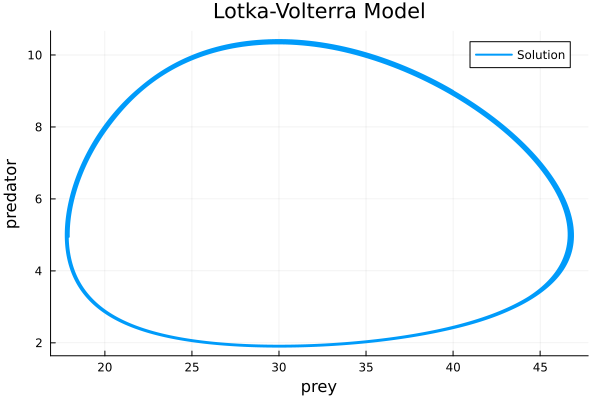

In [76]:
## Lotka-Volterra equations
@parameters α β γ δ
@independent_variables  t
vars = @variables x(t) y(t) z(t)
Dt = Differential(t)
eqs = [
    Dt(x) ~ α * x - β * x * y,
    Dt(y) ~ δ * x * y - γ * y,
]
measured_quantities = [z ~ x + y]  # Example of a measured quantity
@named sys = ODESystem(eqs, t, [x, y], [α, β, γ, δ]; observed = measured_quantities)
sys = complete(sys)
params =  Dict([α => 0.1, 
                β => 0.02, 
                δ => 0.01,
                γ => 0.3])

u0 = Dict([x => 40.0, y => 9.0])
tspan = (0.0, 200.0)
dt = 0.1

sys = complete(sys)
odefun = ODEFunction(sys, unknowns(sys), parameters(sys))
prob = ODEProblem(odefun, [40.0, 9.0], tspan, [0.1, 0.02, 0.01, 0.3])
sol = solve(prob, Tsit5(), saveat=dt)
data = hcat(sol.u...)'
timedata = sol.t
plot(sol, vars=(x, y), xlabel="prey", ylabel="predator",
     title="Lotka-Volterra Model", label="Solution",
     legend=:topright, linewidth=2, markersize=4)


In [4]:
#save model directory
rootdir = dirname(@__DIR__)
model_dir = joinpath(rootdir , "models", "lotka_volterra", "SINDy", "seed_$seed")
#boolean to indicate whether to load models or train models
load_models = true 
model_dir

"c:\\Users\\MGAJ\\OneDrive - Danmarks Tekniske Universitet\\DTU\\Kandidat\\5_Semester\\Speciale\\discovering_hidden_physics\\models\\lotka_volterra\\SINDy\\seed_0"

# Hidden dynamics with SINDy

Assuming only partial knowledge of the Lotka-Volterra equations, we can use SINDy to discover the hidden dynamics.
It's assumed the known dynamics are the ones known whenever a species is present in a vacuum, i.e. when the other species is not present. It's desired to discover the interaction terms between the species, which are not known.
### Known dynamics
These are the dynamics of the species when the other species is not present, i.e. when the other species is in a vacuum.
$$
\begin{align*}
\dot{x} &= \alpha x \\
\dot{y} &= - \gamma y \\
\end{align*}
$$
### Unknown dynamics
# The interaction terms between the species, which are not known.
$$
\begin{align*}
\dot{x} &= - \beta xy \\
\dot{y} &= \delta xy
\end{align*}
$$


In [12]:
known_eqs = [
    Dt(x) ~ α * x
    Dt(y) ~ -γ * y
]
unknown_gt_eqs = [
    Dt(x) ~ -β * x * y,
    Dt(y) ~ δ * x * y,
]
deviance = 0.1 # deviance for the unknown_gt equations
params_guess_known = Dict([α => 0.1, # + deviance * randn()
                        γ => 0.3, # + deviance * randn()])
                        ])

params_guess_unknown_gt = Dict([β => 0.02,# + deviance * randn()
                        δ => 0.01 # + deviance * randn()])
                        ])


@named sys_known = ODESystem(known_eqs, t, [x, y], [α, γ], defaults = params_guess_known, observed = measured_quantities)
@named sys_unknown_gt = ODESystem(unknown_gt_eqs, t, [x, y], [β, δ], defaults = params_guess_unknown_gt)
sys_known = complete(sys_known)
sys_unknown_gt = complete(sys_unknown_gt)

Model sys_unknown_gt:
Equations (2):
  2 standard: see equations(sys_unknown_gt)
Unknowns (2): see unknowns(sys_unknown_gt)
  x(t)
  y(t)
Parameters (2): see parameters(sys_unknown_gt)
  β [defaults to 0.02]
  δ [defaults to 0.01]

# Data for fitting SINDy


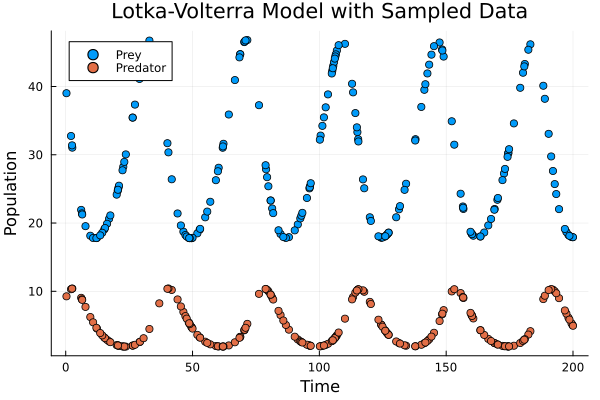

In [101]:
using DataFrames
n_data = size(data, 1)
sample_size = 200

sample_idcs = rand(1:n_data, sample_size)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey" "Predator"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data")

In [103]:
#split train and test data at 80% of the time series
train_fraction = 0.8
test_time = timedata[1:round(Int, n_data * train_fraction)]

prey_df = DataFrame(simulation_id = "cond1", obs_id = "prey_o", time = timedata[sample_idcs], measurement= data[sample_idcs, 1],)
predator_df = DataFrame(simulation_id = "cond1", obs_id = "predator_o", time = timedata[sample_idcs], measurement= data[sample_idcs, 2],)
measurements = vcat(prey_df, predator_df)

#split dataframe into train and test sets
train_idcs = findall(measurements.time .<= test_time[end])
test_idcs = findall(measurements.time .> test_time[end])
#save train and test data½
train_measurements = measurements[train_idcs, :]
test_measurements = measurements[test_idcs, :]

Row,simulation_id,obs_id,time,measurement
,String,String,Float64,Float64
1,cond1,prey_o,169.1,22.0596
2,cond1,prey_o,166.6,19.6528
3,cond1,prey_o,169.0,21.9457
4,cond1,prey_o,163.5,18.0282
5,cond1,prey_o,176.7,34.5963
6,cond1,prey_o,188.3,40.1133
7,cond1,prey_o,183.2,46.1846
8,cond1,prey_o,192.1,27.6266
9,cond1,prey_o,192.8,25.7064


### Proposed basis for SINDy library

In [15]:
function polynomial_basis(x::Array, degree::Int = 1)
    @assert degree > 0
    n_x = length(x)
    n_c = binomial(n_x + degree, degree)
    eqs = Array{Num}(undef, n_c)
    _check_degree(x) = sum(x) <= degree ? true : false
    itr = Base.Iterators.product([0:degree for i in 1:n_x]...)
    itr_ = Base.Iterators.Stateful(Base.Iterators.filter(_check_degree, itr))
    filled = false
    @inbounds for i in 1:n_c
        eqs[i] = 1
        filled = true
        for (xi, ci) in zip(x, popfirst!(itr_))
            if !iszero(ci)
                filled ? eqs[i] = xi^ci : eqs[i] *= xi^ci
                filled = false
            end
        end
    end
    eqs
end

species = unknowns(sys_known)
unknown_basis = polynomial_basis(species, 2) 

6-element Vector{Num}:
         1
      x(t)
    x(t)^2
      y(t)
 x(t)*y(t)
    y(t)^2

In [26]:
using Symbolics, Base

In [59]:
Base.occursin(needle::Num, haystack::Int64) = false # Override occursin for Num types to always return false whenever haystack is an Int64
function create_unknown_eqs(sys_known::AbstractTimeDependentSystem, unknown_basis::Vector{T}; Ξ = nothing) where T <: Union{Num}
    #remove basis functions that are already in the known system
    if isnothing(Ξ)
        @parameters Ξ[1:length(unknown_basis), 1:length(unknowns(sys_known))]
    end 
    known_species = unknowns(sys_known)
    known_eqs = equations(sys_known)
    Ξ = hcat(Ξ)
    #create empty vector to hold the unknown equations
    unknown_eqs = Vector{Any}(undef, length(known_eqs))
    #if equation is already in the known system, remove it from the unknown basis
    for (i,k_eq) in enumerate(known_eqs)
        eq_basis_funs = copy(unknown_basis)
        for (j, basis_fun) in enumerate(unknown_basis)
            if occursin(basis_fun, k_eq.rhs)
                eq_basis_funs[j] = 0
            end
        end
        unknown_eqs[i] = Equation(k_eq.lhs, sum(eq_basis_funs .* Ξ[i, :]))
    end 
    return unknown_eqs
end

create_unknown_eqs (generic function with 1 method)

In [95]:
@parameters Ξ[1:length(known_eqs), 1:length(unknown_basis)]
default_params = Dict([Ξ[i, j] => 0.001 for i in 1:length(known_eqs), j in 1:length(unknown_basis)])
uk_eqs = create_unknown_eqs(sys_known, unknown_basis; Ξ = Ξ)
@named sys_SINDy = ODESystem(uk_eqs, t, defaults = default_params)
sys_SINDy = complete(sys_SINDy)

Model sys_SINDy:
Equations (2):
  2 standard: see equations(sys_SINDy)
Unknowns (2): see unknowns(sys_SINDy)
  x(t)
  y(t)
Parameters (10): see parameters(sys_SINDy)
  Ξ[1, 3] [defaults to 0.001]
  Ξ[2, 5] [defaults to 0.001]
  Ξ[1, 5] [defaults to 0.001]
  Ξ[1, 6] [defaults to 0.001]
  ⋮

┌ Warning: At t=10.112696979746312, dt was forced below floating point epsilon 1.7763568394002505e-15, and step error estimate = 42.16293110332292. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\MGAJ\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623


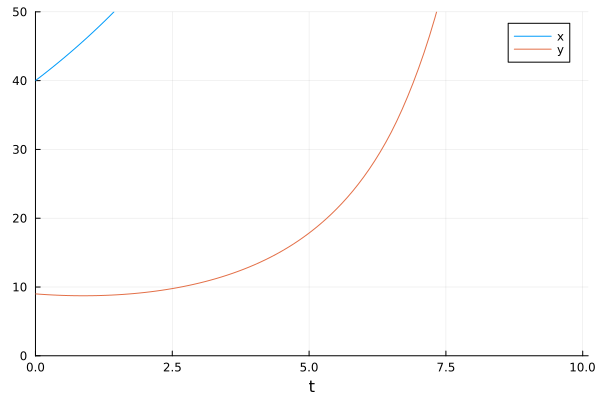

In [96]:
include("../src/hybrid_model.jl")
hmodel = HybridModel(sys_known, sys_SINDy; rng = rng)

initp = init_params(hmodel)
u0vec = ComponentArray(x = 40.0, y = 9.0)

hodeprob = ODEProblem(hmodel, u0vec, tspan, initp)
sol = solve(hodeprob, Tsit5(), saveat=dt)
plot(sol, ylims = (0, 50))

In [129]:
#### PETAB Model
using PEtab
#Setup observables
@parameters σ
obs_x = PEtabObservable(x, σ)
obs_y = PEtabObservable(y, σ)
obs = Dict("prey_o" => obs_x, "predator_o" => obs_y)


#setup initial conditions
cond1 = Dict(:x => 40.0, :y => 9.0)
conds = Dict("cond1" => cond1)
# Setup parameters

#model parameters

estimate = true # Set to true if you want to estimate the parameters
p_α = PEtabParameter(α, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.1)
p_γ = PEtabParameter(γ, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.3)
#noise parameter
p_σ = PEtabParameter(σ, lb = 1e-6, ub = 1e0, estimate = true, scale = :lin, value = 0.2)
pest = [
    p_α,p_γ, p_σ
]
for ξ in parameters(sys_SINDy)
    p_ξ = PEtabParameter(Symbol(string(ξ)), lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.1)
    push!(pest, p_ξ)
end

odesolver = PEtab.ODESolver(Tsit5(); abstol = 1e-6, reltol = 1e-6)

train_model = PEtabModel(hodeprob,obs, train_measurements, pest; simulation_conditions  = conds, verbose = true)
test_model = PEtabModel(hodeprob,obs, test_measurements, pest; simulation_conditions  = conds, verbose = true)
petab_prob = PEtabODEProblem(train_model; odesolver = odesolver)
                             
petab_prob_test = PEtabODEProblem(test_model)

┌Info: Building PEtabModel for model UDEProblemModel
│  Building u0, h and σ functions ... done. Time = 9.4e-04s
└  Building callback (events) functions ... done. Time = 2.0e-07s
┌Info: Building PEtabModel for model UDEProblemModel
│  Building u0, h and σ functions ... done. Time = 8.8e-04s
└  Building callback (events) functions ... done. Time = 3.0e-07s


PEtabODEProblem: UDEProblemModel with ODE-states 2 and 13 parameters to estimate
---------------- Problem options ---------------
Gradient method: ForwardDiff
Hessian method: ForwardDiff
ODE-solver nllh: Rodas5P
ODE-solver gradient: Rodas5P

In [110]:
pest

13-element Vector{PEtabParameter}:
 PEtabParameter: α estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: γ estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: σ estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[1, 3] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[2, 5] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[1, 5] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[1, 6] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[2, 3] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[1, 1] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[2, 1] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[2, 6] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[1, 4] estimated on lin-scale with bounds [1.0e-06, 1.0e+00]
 PEtabParameter: Ξ[2, 2] estimated 

In [112]:
using Optim
n_runs = 20 # Number of runs for multistart optimization
# load_models = false
# if load_models
#     # Load the models from the model directory
#     res = PEtabMultistartResult(model_dir; which_run = 1)
# else
#     # Run the multistart optimization
#     nprocs = 1 # Set the number of processes for parallel optimization
#     res = calibrate_multistart(petab_prob, IPNewton(), n_runs, options = Optim.Options(show_trace = true, iterations = 1000, show_every = 10), nprocs = nprocs; seed = seed, save_trace = true, dirsave = model_dir)
# end

20

In [122]:
using Optimization
using OptimizationOptimJL

opt_prob = OptimizationProblem(petab_prob,box_constraints = false)

OptimizationProblem. In-place: true
u0: ComponentVector{Float64}(α = 0.1, γ = 0.3, σ = 0.2, Ξ[1, 3] = 0.1, Ξ[2, 5] = 0.1, Ξ[1, 5] = 0.1, Ξ[1, 6] = 0.1, Ξ[2, 3] = 0.1, Ξ[1, 1] = 0.1, Ξ[2, 1] = 0.1, Ξ[2, 6] = 0.1, Ξ[1, 4] = 0.1, Ξ[2, 2] = 0.1)

In [130]:
x0 = get_x(petab_prob)


ComponentVector{Float64}(α = 0.1, γ = 0.3, σ = 0.2, Ξ[1, 3] = 0.1, Ξ[2, 5] = 0.1, Ξ[1, 5] = 0.1, Ξ[1, 6] = 0.1, Ξ[2, 3] = 0.1, Ξ[1, 1] = 0.1, Ξ[2, 1] = 0.1, Ξ[2, 6] = 0.1, Ξ[1, 4] = 0.1, Ξ[2, 2] = 0.1)

In [131]:
x0 = get_x(petab_prob)
opt_prob.u0 .= x0
res = solve(opt_prob, Optim.Adam())

OrdinaryDiffEqDifferentiation.FirstAutodiffJacError: First call to automatic differentiation for the Jacobian
failed. This means that the user `f` function is not compatible
with automatic differentiation. Methods to fix this include:

1. Turn off automatic differentiation (e.g. Rosenbrock23() becomes
   Rosenbrock23(autodiff = AutoFiniteDiff())). More details can befound at
   https://docs.sciml.ai/DiffEqDocs/stable/features/performance_overloads/
2. Improving the compatibility of `f` with ForwardDiff.jl automatic
   differentiation (using tools like PreallocationTools.jl). More details
   can be found at https://docs.sciml.ai/DiffEqDocs/stable/basics/faq/#Autodifferentiation-and-Dual-Numbers
3. Defining analytical Jacobians. More details can be
   found at https://docs.sciml.ai/DiffEqDocs/stable/types/ode_types/#SciMLBase.ODEFunction

Note: turning off automatic differentiation tends to have a very minimal
performance impact (for this use case, because it's forward mode for a
square 